In [1]:
import os
import gc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import warnings


warnings.simplefilter(action='ignore', category=FutureWarning)

data_prefix_path = r"E:/archive/ecommerce_oct/"

['behavior_counts',
 'brand_conversion_rates',
 'category_conversion_rates',
 'cleaned',
 'daily_active_users',
 'daily_behavior',
 'daily_sales',
 'df_merged_session',
 'heatmap_hour_weekday',
 'hourly_behavior',
 'product_price',
 'product_price_desc',
 'sales_by_weekday',
 'session_paths',
 'top10_brands',
 'top10_brands_cart',
 'top10_brands_purchase',
 'top10_brands_view',
 'top10_categories',
 'top10_categories_cart',
 'top10_categories_purchase',
 'top10_categories_stats',
 'top10_categories_view',
 'unique_users_by_event',
 'weekly_behavior',
 'weekly_sales',
 'weekly_sales_top_categories']

 /csv/

### behavior counts

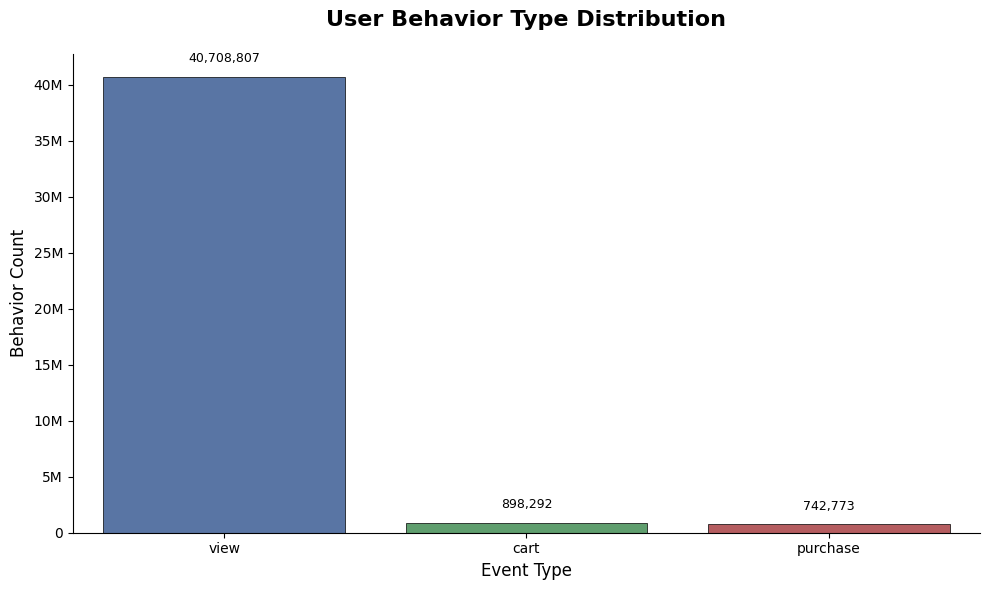

In [8]:
path =os.path.join(data_prefix_path, "behavior_counts/csv/", "part-00000-e6faa8c5-c8f7-42d6-a988-c5c1387000a3-c000.csv")
df = pd.read_csv(path)

# plt.figure(figsize=(10,6), facecolor="lightgray")
# ax = plt.gca()
# ax.set_facecolor("lightgray")

# bars = sns.barplot(x=df["event_type"], y=df["count"], palette='viridis', ax=ax)
# ax.bar_label(bars.containers[0], fmt='%d', label_type='edge')

# plt.title('User behavior type distribution')
# plt.ylabel('behavior_count')
# plt.xticks(rotation=0)
# plt.show()
# 排序以确保“view”在前（可选）
df = df.sort_values(by="count", ascending=False)

# 创建图形
plt.figure(figsize=(10, 6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

# 使用更柔和且对比明显的调色板
colors = ['#4C72B0', '#55A868', '#C44E52']  # blue, green, red
bars = sns.barplot(x=df["event_type"], y=df["count"], palette=colors, ax=ax, edgecolor='black', linewidth=0.5)

# 添加数值标签（在柱子上方）
for i, v in enumerate(df["count"]):
    ax.text(i, v + 1e6, f'{v:,}', ha='center', va='bottom', fontsize=9, color='black')

# 标题和轴标签
plt.title('User Behavior Type Distribution', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Behavior Count', fontsize=12)
plt.xlabel('Event Type', fontsize=12)

# 优化坐标轴
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', labelsize=10)

# 设置 y 轴为科学计数法格式（避免大数字拥挤）
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, p: f'{int(x/1e6)}M' if x >= 1e6 else f'{x:.0f}'))

# 可选：移除顶部和右边框线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 调整布局，防止标签被截断
plt.tight_layout()

# 显示图表
plt.show()


In [15]:
df.head()

,event_type,count
0,view,40708807
1,cart,898292
2,purchase,742773


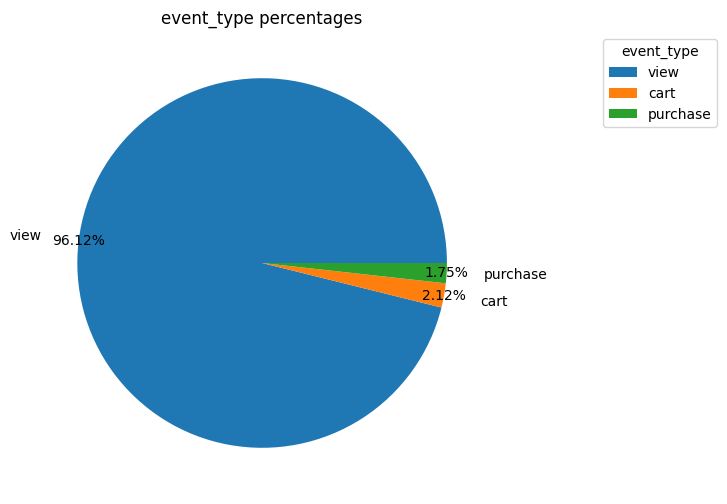

2862

In [11]:
plt.figure(figsize=(10,6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

plt.pie(df['count'], autopct='%.2f%%', pctdistance=1, labels=df['event_type'], 
        labeldistance=1.2)
plt.title('event_type percentages')
plt.legend(labels=df['event_type'], title='event_type', bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

del ax
plt.close()
gc.collect()

### 每日用户行为趋势分析

In [40]:
path =os.path.join(data_prefix_path, "daily_behavior/csv/", "part-00000-34edd48c-012d-44ae-add1-0e4690b4184d-c000.csv")
df = pd.read_csv(path)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['behavior_count'] = pd.to_numeric(df['behavior_count'], errors='coerce')
df['event_type'] = df['event_type'].astype(str).str.strip()  # 去掉可能的空格

# 删除有空值的行
df = df.dropna(subset=['date', 'behavior_count', 'event_type'])

In [41]:
print(df.dtypes)
print(df['event_type'].unique())


date              datetime64[ns]
event_type                object
behavior_count             int64
dtype: object
['cart' 'purchase' 'view']


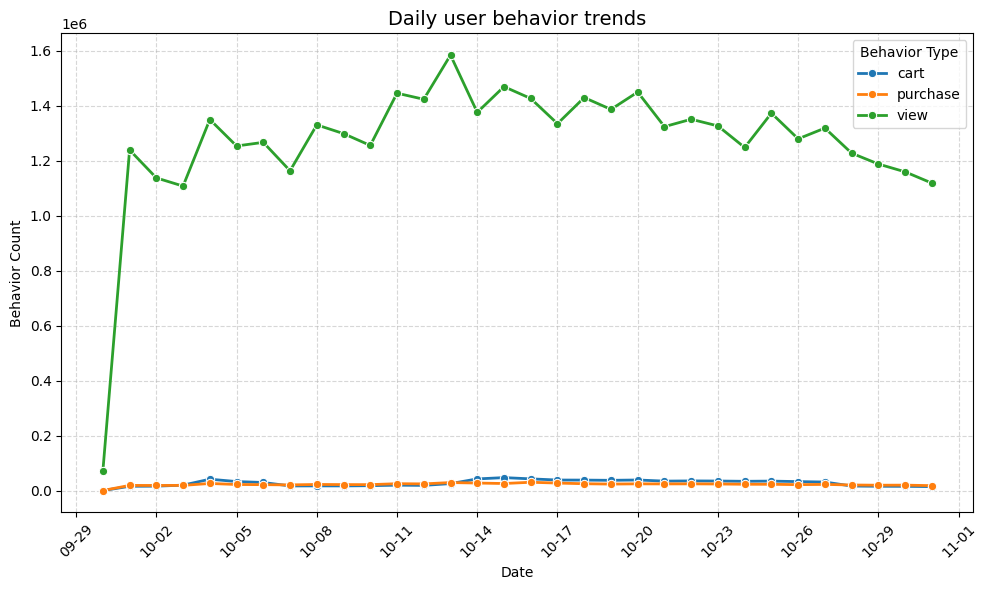

29013

In [45]:
plt.figure(figsize=(10,6), facecolor="white")

palette = {'cart': 'tab:blue', 'purchase': 'tab:orange', 'view': 'tab:green'}

sns.lineplot(
    data=df,
    x='date',
    y='behavior_count',
    hue='event_type',
    palette=palette,
    marker='o',
    linewidth=2,
    errorbar=None
)

plt.title('Daily user behavior trends', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Behavior Count')

ax = plt.gca()
ax.set_facecolor("white")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Behavior Type')
plt.tight_layout()
plt.show()

del df, ax
plt.close()
gc.collect()



### 每周用户行为趋势分析

In [54]:
path =os.path.join(data_prefix_path, "weekly_behavior/csv/", "part-00000-8afa8cc1-a9ce-4b9f-81a6-dbe0e1a505da-c000.csv")
df = pd.read_csv(path)
df.head()

,weekday,event_type,behavior_count
0,5,view,5342604
1,2,cart,130199
2,6,purchase,101157
3,0,purchase,97316
4,5,purchase,95214


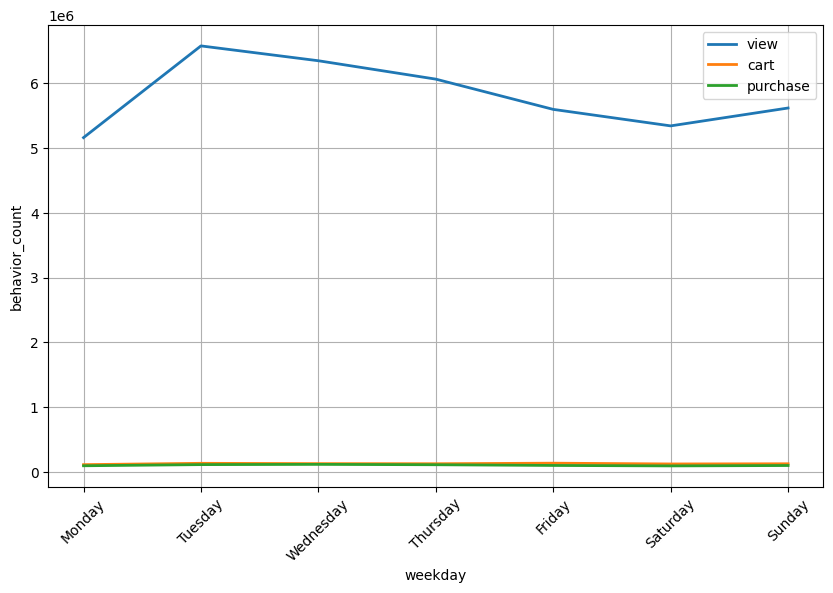

15447

In [ ]:
plt.figure(figsize=(10, 6), facecolor="white")
sns.lineplot(
    data=df,
    x='weekday',
    y='behavior_count',
    hue='event_type',
    linewidth=2,
    errorbar=None
)
plt.xticks(ticks=range(7), 
           labels=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"], 
           rotation=45)
plt.grid()
plt.legend()
plt.show()

# del df
# plt.close()
# gc.collect()

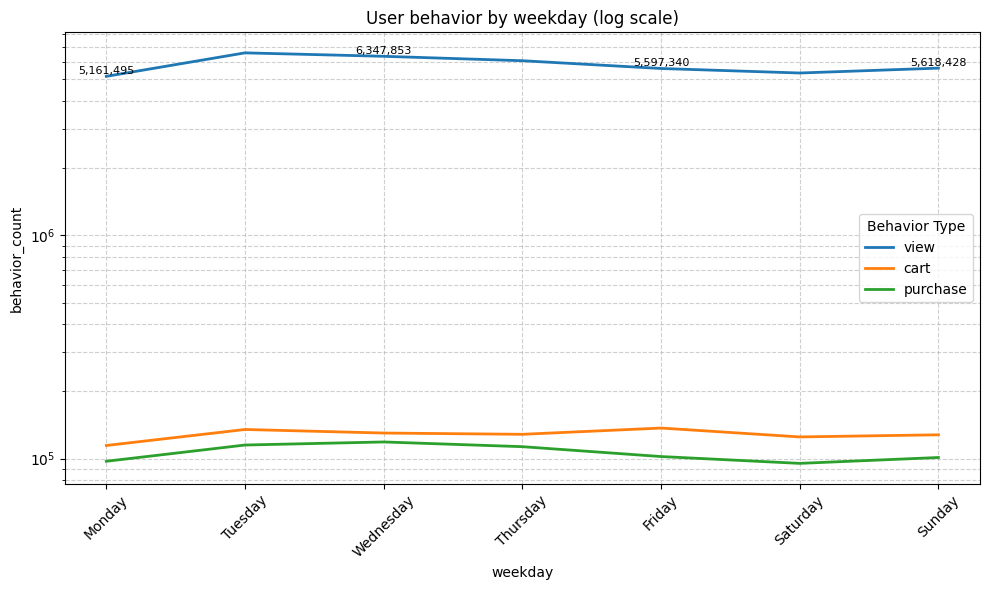

In [57]:
plt.figure(figsize=(10, 6), facecolor="white")

sns.lineplot(
    data=df,
    x='weekday',
    y='behavior_count',
    hue='event_type',
    linewidth=2,
    errorbar=None
)

plt.yscale('log')
plt.xticks(
    ticks=range(7), 
    labels=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"], 
    rotation=45
)
plt.title("User behavior by weekday (log scale)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend(title="Behavior Type")

# ==== ⭐ 在蓝线(view)上显示数值标签 ====
view_data = df[df['event_type'] == 'view']
for i, row in view_data.iterrows():
    # 只在部分点上标注，避免太密
    if row['weekday'] in [0, 2, 4, 6]:  # Monday, Wednesday, Friday, Sunday
        plt.text(
            row['weekday'], 
            row['behavior_count'], 
            f"{int(row['behavior_count']):,}", 
            color='black', 
            fontsize=8, 
            ha='center', 
            va='bottom'
        )

plt.tight_layout()
plt.show()


### 每小时用户行为趋势分析

In [58]:
path =os.path.join(data_prefix_path, "hourly_behavior/csv/", "part-00000-a1bb2592-e025-465f-b4fe-9bf4cd956ae2-c000.csv")
df = pd.read_csv(path)
df.head()


,hour,event_type,behavior_count
0,23,cart,33641
1,5,view,2225529
2,2,cart,60599
3,10,purchase,37363
4,21,cart,7523


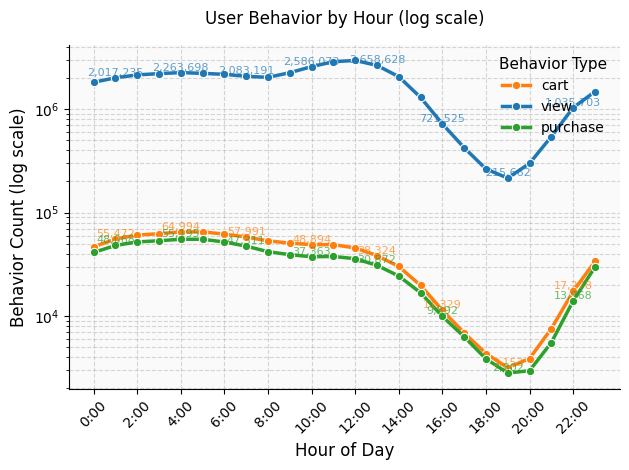

In [ ]:
palette = {
    'view': '#1f77b4',
    'cart': '#ff7f0e',
    'purchase': '#2ca02c'
}

sns.lineplot(
    data=df,
    x='hour',
    y='behavior_count',
    hue='event_type',
    palette=palette,
    linewidth=2.5,
    marker='o',
    errorbar=None
)

plt.yscale('log')

plt.xticks(
    ticks=range(0, 24, 2),
    labels=[f"{h}:00" for h in range(0, 24, 2)],
    rotation=45
)

plt.title("User Behavior by Hour (log scale)", fontsize=12, pad=15)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Behavior Count (log scale)", fontsize=12)

plt.grid(True, which='both', linestyle='--', alpha=0.5)
ax = plt.gca()
ax.set_facecolor('#fafafa')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

k = 1
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        if y > 0:
            k += 1
            if k % 3 == 0:
                ax.text(
                    x, y,
                    f"{int(y):,}",
                    color=line.get_color(),
                    fontsize=8,
                    ha='center',
                    va='bottom',
                    alpha=0.7
                )

# 🧭 图例
plt.legend(
    title="Behavior Type",
    title_fontsize=11,
    fontsize=10,
    loc='upper right',
    frameon=False
)

plt.tight_layout()
plt.show()